# Credit Risk Probability Model for Alternative Data

## Exploratory Data Analysis (EDA)

### Bati Bank — Buy Now Pay Later Credit Scoring Project

**Prepared by:** Mariamawit Ewnetu Alemu  
**Program:** 10 Academy — Artificial Intelligence Mastery  
**Week:** 4 Challenge  
**Date:** May 2026

---

## Objective

This notebook performs exploratory data analysis on the Xente eCommerce transaction dataset. The analysis focuses on understanding customer transaction behavior, identifying data quality issues, analyzing numerical and categorical feature distributions, detecting outliers, and generating insights that will guide future feature engineering and proxy credit risk modeling.

The dataset does not contain a direct loan default label. Therefore, behavioral patterns extracted from transaction activity will later be used to engineer a proxy high-risk target variable using RFM analysis.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

# 1. Data Loading

In [2]:
df = pd.read_csv("../data/raw/data.csv")

definitions = pd.read_csv(
    "../data/raw/Xente_Variable_Definitions.csv"
)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (95662, 16)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [ ]:
required_columns = [
    "TransactionId", "CustomerId", "Amount", "Value",
    "ProductCategory", "ChannelId", "PricingStrategy",
    "FraudResult", "TransactionStartTime"
]

missing_required_columns = [
    col for col in required_columns if col not in df.columns
]

if missing_required_columns:
    raise ValueError(
        f"Missing required columns: {missing_required_columns}"
    )
else:
    print("All required columns are present.")

## Variable Definitions

In [3]:
definitions

,Column Name,Definition
0,TransactionId,Unique �transaction identifier on platform
1,BatchId,Unique number assigned to a batch of transacti...
2,AccountId,Unique number identifying the customer on plat...
3,SubscriptionId,Unique number identifying the customer subscri...
4,CustomerId,Unique identifier attached to Account
5,CurrencyCode,Country currency
6,CountryCode,Numerical geographical code of country
7,ProviderId,Source provider of Item �bought.
8,ProductId,Item name being bought.
9,ProductCategory,ProductIds are organized into these broader pr...


# 2. Dataset Overview

In [4]:
overview = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Unique Customers",
        "Unique Transactions",
        "Unique Product Categories",
        "Unique Providers",
        "Unique Channels"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df["CustomerId"].nunique(),
        df["TransactionId"].nunique(),
        df["ProductCategory"].nunique(),
        df["ProviderId"].nunique(),
        df["ChannelId"].nunique()
    ]
})

overview

,Metric,Value
0,Rows,95662
1,Columns,16
2,Unique Customers,3742
3,Unique Transactions,95662
4,Unique Product Categories,9
5,Unique Providers,6
6,Unique Channels,4


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult        

### Insight

The dataset contains transaction-level behavioral data collected from customers using the Xente eCommerce platform. The presence of customer identifiers, transaction values, timestamps, channels, and product categories provides a strong foundation for future behavioral credit risk modeling.

# 3. Missing Value Analysis

In [6]:
missing_values = (
    df.isnull()
    .sum()
    .reset_index()
)

missing_values.columns = [
    "Column",
    "Missing Values"
]

missing_values["Percentage"] = (
    missing_values["Missing Values"]
    / len(df)
) * 100

missing_values.sort_values(
    by="Missing Values",
    ascending=False
)

,Column,Missing Values,Percentage
0,TransactionId,0,0.0
1,BatchId,0,0.0
2,AccountId,0,0.0
3,SubscriptionId,0,0.0
4,CustomerId,0,0.0
5,CurrencyCode,0,0.0
6,CountryCode,0,0.0
7,ProviderId,0,0.0
8,ProductId,0,0.0
9,ProductCategory,0,0.0


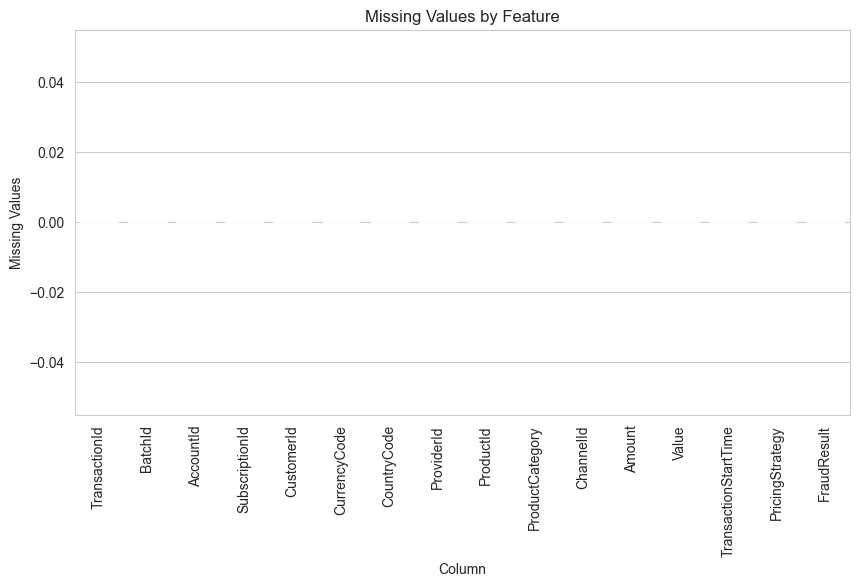

In [7]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=missing_values,
    x="Column",
    y="Missing Values"
)

plt.xticks(rotation=90)

plt.title("Missing Values by Feature")

plt.show()

### Insight

The dataset contains very limited missing values, suggesting relatively strong transactional data quality. Maintaining complete customer behavior records is important because missing information may weaken future risk prediction performance.

# 4. Duplicate Analysis

In [8]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


### Insight

Duplicate financial transactions may distort customer-level behavioral metrics such as transaction frequency and total spending. Therefore, checking duplicate records is important before feature engineering.

# 5. Summary Statistics

In [9]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


### Insight

Transaction amounts and values show substantial variability and skewness, indicating that customer spending behavior differs significantly across the platform.

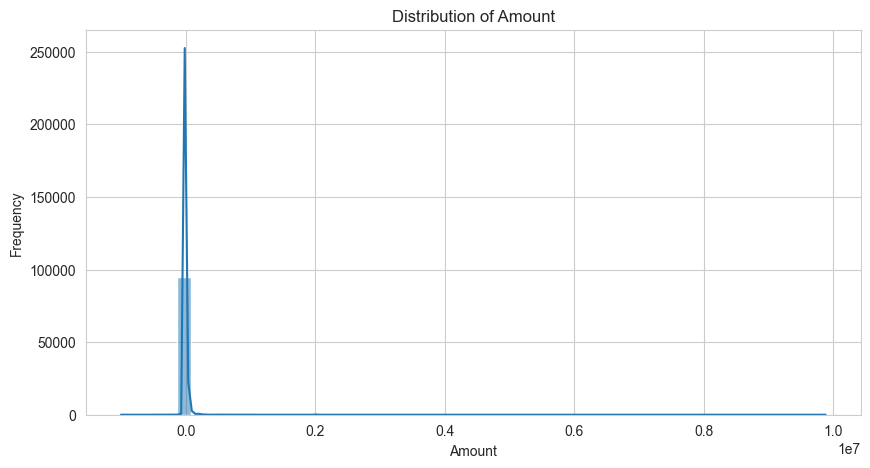

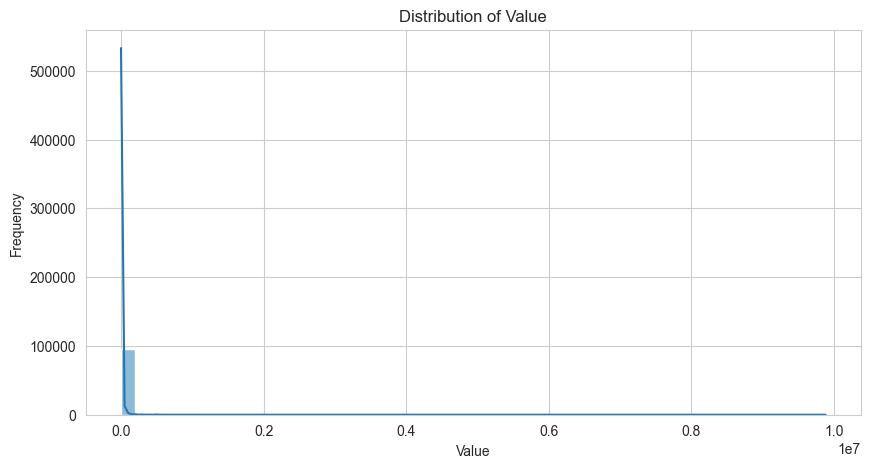

In [10]:
numerical_cols = ["Amount", "Value"]

for col in numerical_cols:

    plt.figure(figsize=(10,5))

    sns.histplot(
        df[col],
        bins=50,
        kde=True
    )

    plt.title(f"Distribution of {col}")

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()

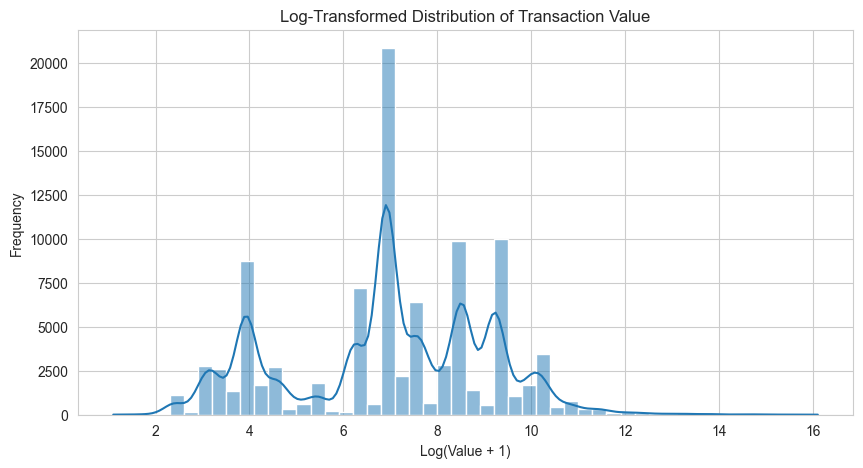

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(df["Value"]),
    bins=50,
    kde=True
)

plt.title(
    "Log-Transformed Distribution of Transaction Value"
)

plt.xlabel("Log(Value + 1)")

plt.ylabel("Frequency")

plt.show()

### Insight

Transaction values are highly right-skewed. Most transactions are relatively small, while a small number of transactions are extremely large. This indicates the potential need for scaling or transformation during future modeling stages.

# 7. Categorical Feature Analysis

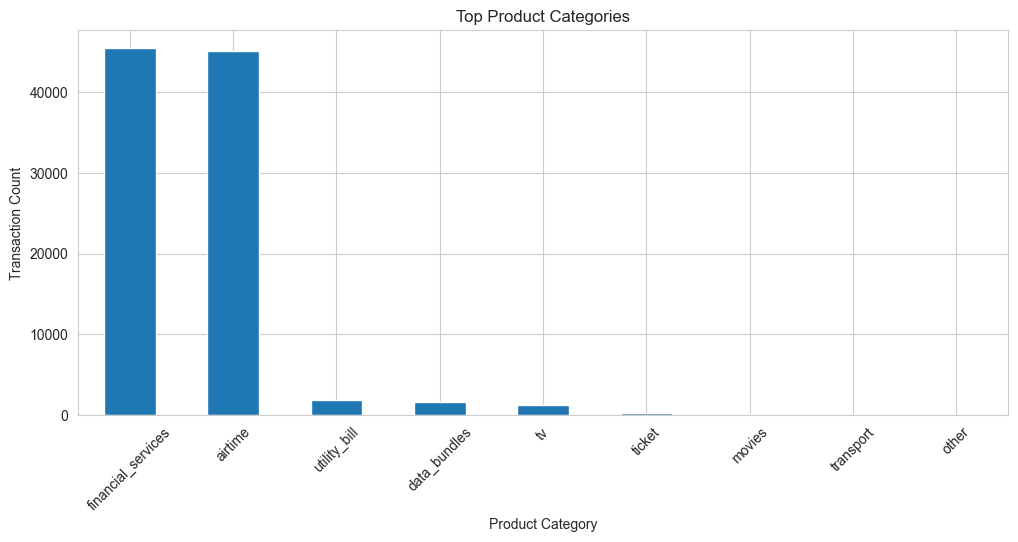

In [12]:
plt.figure(figsize=(12,5))

df["ProductCategory"]\
    .value_counts()\
    .head(10)\
    .plot(kind="bar")

plt.title("Top Product Categories")

plt.xlabel("Product Category")

plt.ylabel("Transaction Count")

plt.xticks(rotation=45)

plt.show()

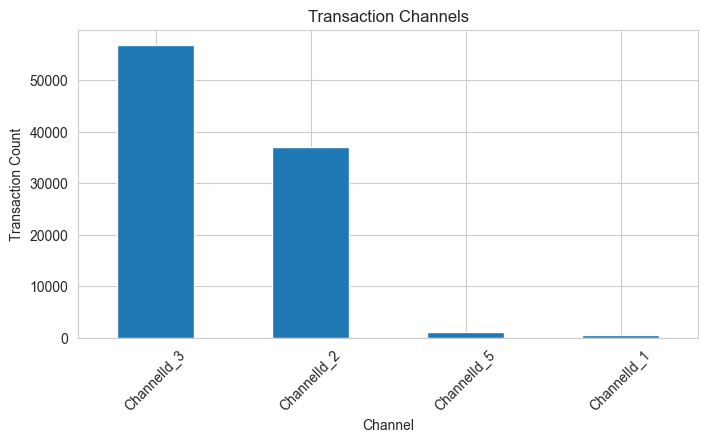

In [13]:
plt.figure(figsize=(8,4))

df["ChannelId"]\
    .value_counts()\
    .plot(kind="bar")

plt.title("Transaction Channels")

plt.xlabel("Channel")

plt.ylabel("Transaction Count")

plt.xticks(rotation=45)

plt.show()

### Insight

Certain product categories dominate customer activity, suggesting concentrated purchasing behavior. Transaction channels also provide insight into how customers interact with the platform and may later contribute to behavioral segmentation.

# 8. Fraud Distribution

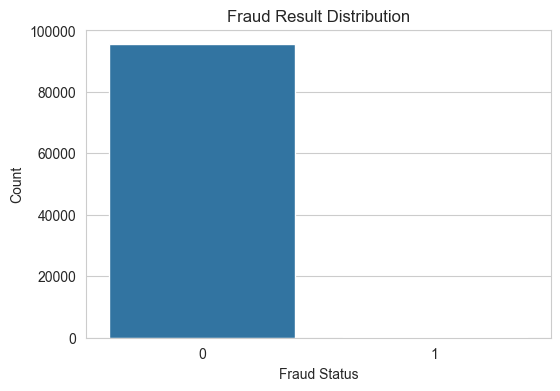

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="FraudResult",
    data=df
)

plt.title("Fraud Result Distribution")

plt.xlabel("Fraud Status")

plt.ylabel("Count")

plt.show()

### Insight

Fraudulent transactions represent a relatively small portion of the dataset, indicating class imbalance. This may later influence model evaluation metrics and sampling strategies.

# 9. Time-Based Transaction Analysis

In [15]:
df["TransactionStartTime"] = pd.to_datetime(
    df["TransactionStartTime"]
)

df["TransactionHour"] = (
    df["TransactionStartTime"].dt.hour
)

df["TransactionDay"] = (
    df["TransactionStartTime"].dt.day
)

df["TransactionMonth"] = (
    df["TransactionStartTime"].dt.month
)

df["TransactionYear"] = (
    df["TransactionStartTime"].dt.year
)

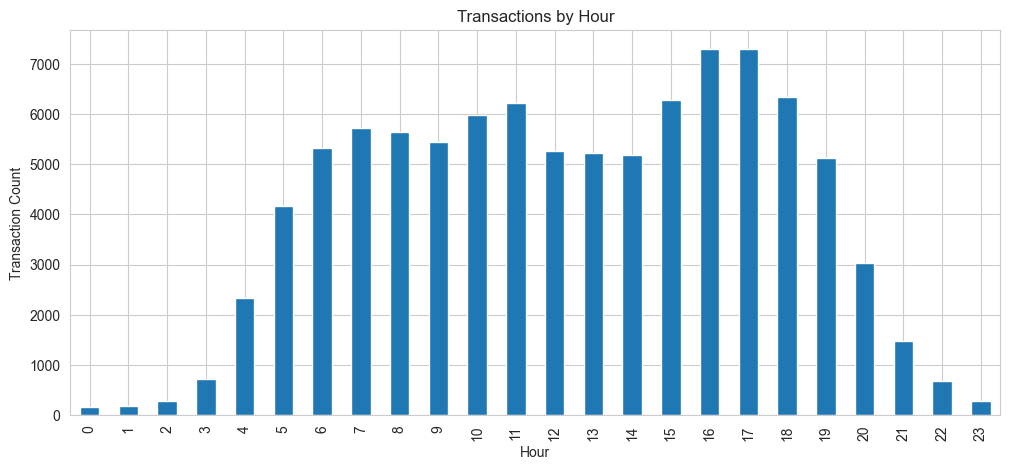

In [16]:
plt.figure(figsize=(12,5))

df["TransactionHour"]\
    .value_counts()\
    .sort_index()\
    .plot(kind="bar")

plt.title("Transactions by Hour")

plt.xlabel("Hour")

plt.ylabel("Transaction Count")

plt.show()

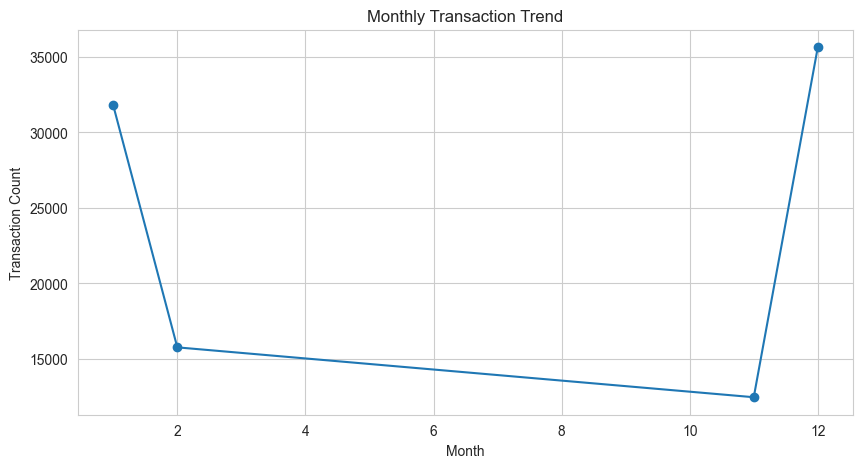

In [17]:
monthly_transactions = (
    df.groupby("TransactionMonth")
    .size()
)

plt.figure(figsize=(10,5))

monthly_transactions.plot(marker="o")

plt.title("Monthly Transaction Trend")

plt.xlabel("Month")

plt.ylabel("Transaction Count")

plt.grid(True)

plt.show()

### Insight

Transaction timing patterns may reveal behavioral trends and purchasing habits. These temporal features may later contribute to customer segmentation and proxy credit risk analysis.

# 10. Correlation Analysis

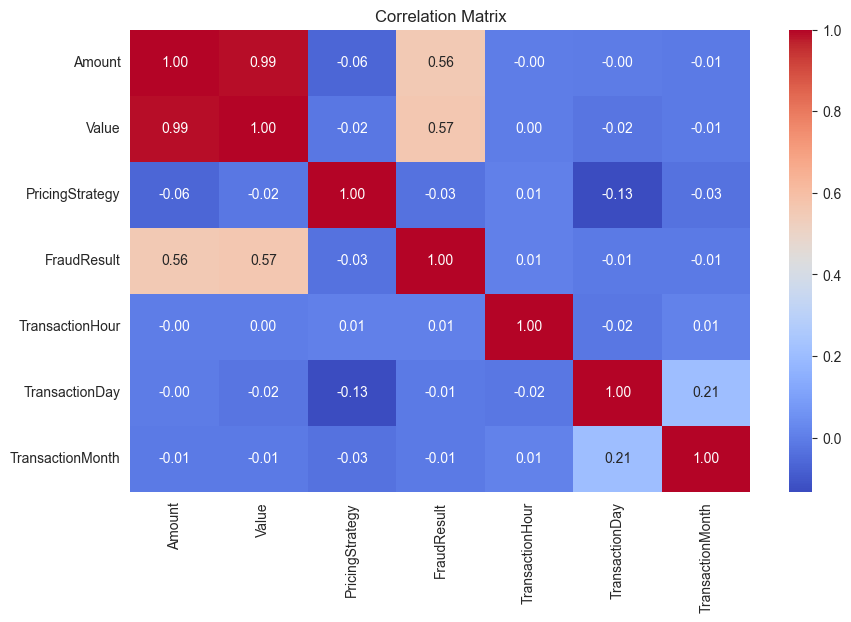

In [18]:
corr_cols = [
    "Amount",
    "Value",
    "PricingStrategy",
    "FraudResult",
    "TransactionHour",
    "TransactionDay",
    "TransactionMonth"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Insight

Amount and Value are strongly correlated because they represent related transaction measures. Most other variables demonstrate weak linear relationships, suggesting that engineered behavioral features may later become more informative predictors.

This suggests that customer-level engineered behavioral features may ultimately contribute more predictive power than raw transaction-level variables alone.

# 11. Outlier Detection

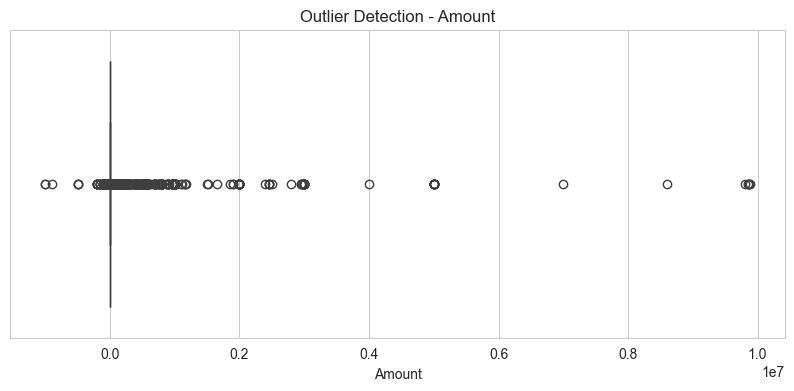

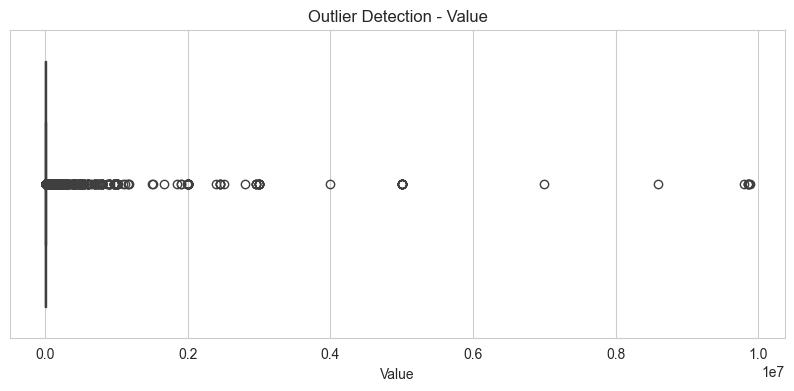

In [19]:
for col in ["Amount", "Value"]:

    plt.figure(figsize=(10,4))

    sns.boxplot(x=df[col])

    plt.title(f"Outlier Detection - {col}")

    plt.show()

### Insight

Significant outliers exist within transaction values and amounts. Such behavior is common in financial systems but may affect model stability if not handled carefully during preprocessing.

# 12. Customer-Level Aggregation

In [20]:
customer_features = df.groupby(
    "CustomerId"
).agg(
    total_transaction_amount=(
        "Amount",
        "sum"
    ),
    average_transaction_amount=(
        "Amount",
        "mean"
    ),
    transaction_count=(
        "TransactionId",
        "count"
    ),
    std_transaction_amount=(
        "Amount",
        "std"
    ),
    total_transaction_value=(
        "Value",
        "sum"
    )
).reset_index()

customer_features.head()

,CustomerId,total_transaction_amount,average_transaction_amount,transaction_count,std_transaction_amount,total_transaction_value
0,CustomerId_1,-10000.0,-10000.000000,1,NaN,10000
1,CustomerId_10,-10000.0,-10000.000000,1,NaN,10000
2,CustomerId_1001,20000.0,4000.000000,5,6558.963333,30400
3,CustomerId_1002,4225.0,384.090909,11,560.498966,4775
4,CustomerId_1003,20000.0,3333.333333,6,6030.478146,32000


In [21]:
customer_features.describe()

,total_transaction_amount,average_transaction_amount,transaction_count,std_transaction_amount,total_transaction_value
count,3.742000e+03,3.742000e+03,3742.000000,3.030000e+03,3.742000e+03
mean,1.717377e+05,1.571562e+04,25.564404,1.680216e+04,2.531025e+05
std,2.717305e+06,1.676991e+05,96.929602,1.074311e+05,2.715877e+06
min,-1.049000e+08,-4.250000e+05,1.000000,0.000000e+00,5.000000e+01
25%,4.077438e+03,1.000000e+03,2.000000,1.533574e+03,6.500000e+03
50%,2.000000e+04,2.583846e+03,7.000000,5.389779e+03,3.200000e+04
75%,7.996775e+04,4.877614e+03,20.000000,7.549050e+03,1.020600e+05
max,8.345124e+07,8.601821e+06,4091.000000,3.309916e+06,1.049000e+08


### Insight

Credit scoring is ultimately performed at the customer level rather than the transaction level. Therefore, customer aggregation is a critical preprocessing step for future modeling.

# 13. RFM Analysis Preview

In [22]:
snapshot_date = (
    df["TransactionStartTime"].max()
    + pd.Timedelta(days=1)
)

rfm = df.groupby("CustomerId").agg(
    Recency=(
        "TransactionStartTime",
        lambda x: (
            snapshot_date - x.max()
        ).days
    ),
    Frequency=(
        "TransactionId",
        "count"
    ),
    Monetary=(
        "Value",
        "sum"
    )
).reset_index()

rfm.head()

,CustomerId,Recency,Frequency,Monetary
0,CustomerId_1,84,1,10000
1,CustomerId_10,84,1,10000
2,CustomerId_1001,90,5,30400
3,CustomerId_1002,26,11,4775
4,CustomerId_1003,12,6,32000


In [23]:
rfm.describe()

,Recency,Frequency,Monetary
count,3742.000000,3742.000000,3.742000e+03
mean,31.461251,25.564404,2.531025e+05
std,27.118932,96.929602,2.715877e+06
min,1.000000,1.000000,5.000000e+01
25%,6.000000,2.000000,6.500000e+03
50%,25.000000,7.000000,3.200000e+04
75%,54.000000,20.000000,1.020600e+05
max,91.000000,4091.000000,1.049000e+08


### Insight

RFM metrics provide a behavioral representation of customer engagement. Customers with low frequency, low monetary value, and long inactivity periods may later be classified as higher-risk proxy customers.

# 14. Key Interim EDA Insights

## 1. The dataset is suitable for behavioral credit risk modeling

The transaction-level structure captures detailed customer activity patterns that can later be transformed into customer-level risk indicators.

## 2. Transaction values are highly skewed

Most transactions are relatively small while a minority are extremely large. This suggests the need for scaling and transformation during feature engineering.

## 3. Product categories and transaction channels show meaningful behavioral variation

These categorical variables are likely to contain predictive information useful for future credit scoring.

## 4. Customer-level aggregation is essential

Credit risk decisions apply to customers rather than individual transactions. Customer aggregation will therefore be central to future modeling.

## 5. RFM analysis provides a defensible foundation for proxy target engineering

Since the dataset lacks a true default label, Recency, Frequency, and Monetary behavior provide a practical approach for constructing a proxy high-risk target.

In [24]:
df.shape

(95662, 20)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   TransactionId         95662 non-null  object             
 1   BatchId               95662 non-null  object             
 2   AccountId             95662 non-null  object             
 3   SubscriptionId        95662 non-null  object             
 4   CustomerId            95662 non-null  object             
 5   CurrencyCode          95662 non-null  object             
 6   CountryCode           95662 non-null  int64              
 7   ProviderId            95662 non-null  object             
 8   ProductId             95662 non-null  object             
 9   ProductCategory       95662 non-null  object             
 10  ChannelId             95662 non-null  object             
 11  Amount                95662 non-null  float64            
 12  Valu

In [26]:
definitions

,Column Name,Definition
0,TransactionId,Unique �transaction identifier on platform
1,BatchId,Unique number assigned to a batch of transacti...
2,AccountId,Unique number identifying the customer on plat...
3,SubscriptionId,Unique number identifying the customer subscri...
4,CustomerId,Unique identifier attached to Account
5,CurrencyCode,Country currency
6,CountryCode,Numerical geographical code of country
7,ProviderId,Source provider of Item �bought.
8,ProductId,Item name being bought.
9,ProductCategory,ProductIds are organized into these broader pr...


# Exploratory Data Analysis — Credit Risk Probability Model

**Project:** Bati Bank Alternative Credit Scoring  
**Dataset:** Xente eCommerce Transactions  
**Objective:** Explore transaction behavior to support future credit risk proxy modeling.

This notebook supports the Week 4 interim submission. It focuses on understanding the dataset structure, data quality, feature distributions, customer transaction behavior, correlations, and early business insights.

In [27]:
overview = pd.DataFrame({
    "Metric": [
        "Number of rows",
        "Number of columns",
        "Number of unique customers",
        "Number of unique transactions",
        "Number of product categories",
        "Number of providers",
        "Number of channels"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df["CustomerId"].nunique(),
        df["TransactionId"].nunique(),
        df["ProductCategory"].nunique(),
        df["ProviderId"].nunique(),
        df["ChannelId"].nunique()
    ]
})

overview

,Metric,Value
0,Number of rows,95662
1,Number of columns,20
2,Number of unique customers,3742
3,Number of unique transactions,95662
4,Number of product categories,9
5,Number of providers,6
6,Number of channels,4


In [28]:
missing = df.isnull().sum().reset_index()
missing.columns = ["Column", "Missing_Count"]
missing["Missing_Percentage"] = (missing["Missing_Count"] / len(df)) * 100
missing

,Column,Missing_Count,Missing_Percentage
0,TransactionId,0,0.0
1,BatchId,0,0.0
2,AccountId,0,0.0
3,SubscriptionId,0,0.0
4,CustomerId,0,0.0
5,CurrencyCode,0,0.0
6,CountryCode,0,0.0
7,ProviderId,0,0.0
8,ProductId,0,0.0
9,ProductCategory,0,0.0


In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult,TransactionHour,TransactionDay,TransactionMonth,TransactionYear
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000,95662.000000,95662.000000,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018,12.447722,15.902898,6.566233,2018.497115
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872,4.846964,8.962822,5.224310,0.499994
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000,0.000000,1.000000,1.000000,2018.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000,8.000000,8.000000,1.000000,2018.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000,13.000000,16.000000,11.000000,2018.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000,17.000000,24.000000,12.000000,2019.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000,23.000000,31.000000,12.000000,2019.000000


In [31]:
categorical_cols = [
    "CurrencyCode", "CountryCode", "ProviderId", "ProductId",
    "ProductCategory", "ChannelId", "PricingStrategy", "FraudResult"
]

for col in categorical_cols:
    display(df[col].value_counts().head(10))

CurrencyCode
UGX    95662
Name: count, dtype: int64

CountryCode
256    95662
Name: count, dtype: int64

ProviderId
ProviderId_4    38189
ProviderId_6    34186
ProviderId_5    14542
ProviderId_1     5643
ProviderId_3     3084
ProviderId_2       18
Name: count, dtype: int64

ProductId
ProductId_6     32635
ProductId_3     24344
ProductId_10    15384
ProductId_15    11964
ProductId_1      2885
ProductId_4      2403
ProductId_21     1512
ProductId_11     1377
ProductId_19      965
ProductId_14      789
Name: count, dtype: int64

ProductCategory
financial_services    45405
airtime               45027
utility_bill           1920
data_bundles           1613
tv                     1279
ticket                  216
movies                  175
transport                25
other                     2
Name: count, dtype: int64

ChannelId
ChannelId_3    56935
ChannelId_2    37141
ChannelId_5     1048
ChannelId_1      538
Name: count, dtype: int64

PricingStrategy
2    79848
4    13562
1     1867
0      385
Name: count, dtype: int64

FraudResult
0    95469
1      193
Name: count, dtype: int64

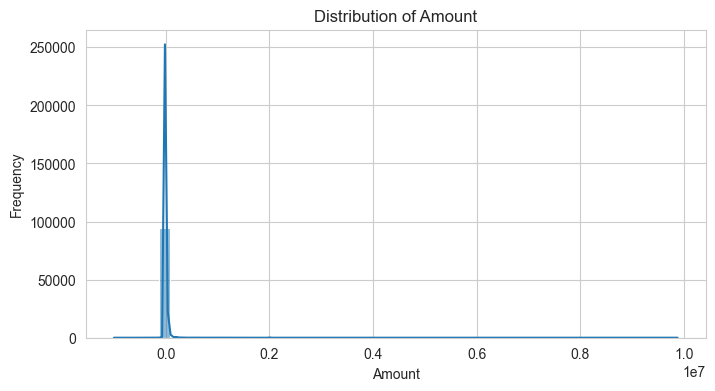

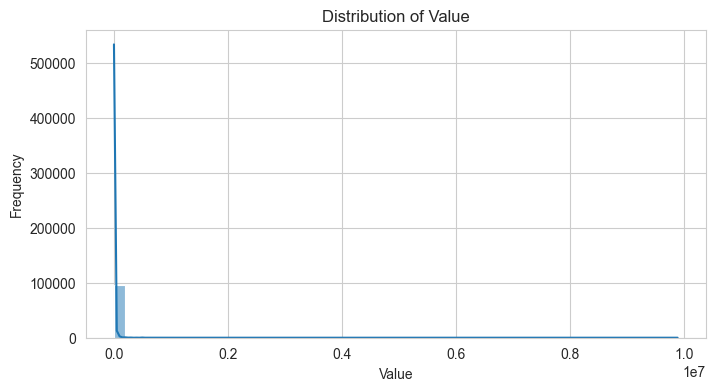

In [32]:
numerical_cols = ["Amount", "Value"]

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

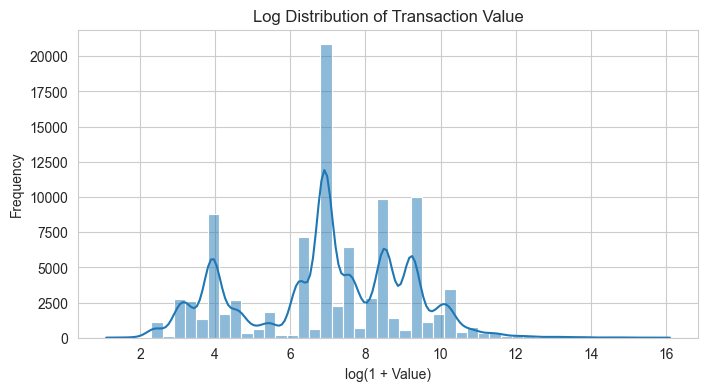

In [33]:
plt.figure(figsize=(8, 4))
sns.histplot(np.log1p(df["Value"]), bins=50, kde=True)
plt.title("Log Distribution of Transaction Value")
plt.xlabel("log(1 + Value)")
plt.ylabel("Frequency")
plt.show()

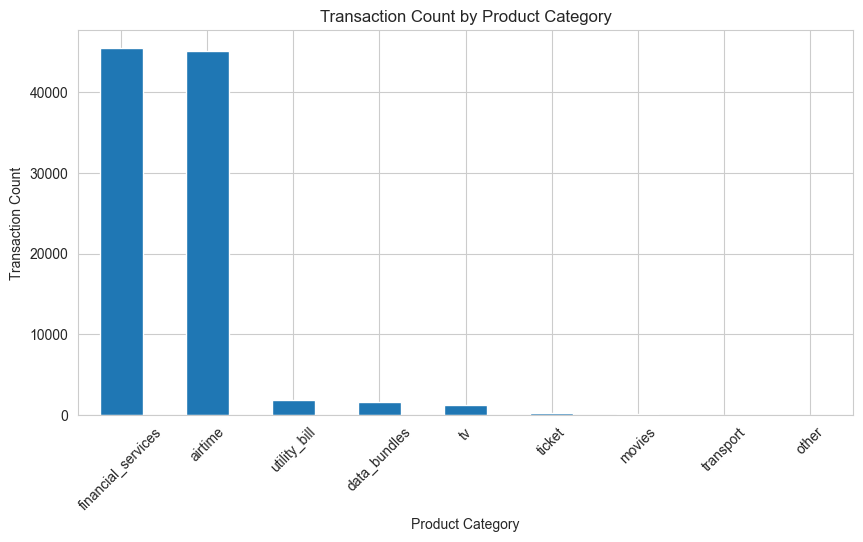

In [34]:
plt.figure(figsize=(10, 5))
df["ProductCategory"].value_counts().plot(kind="bar")
plt.title("Transaction Count by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.show()

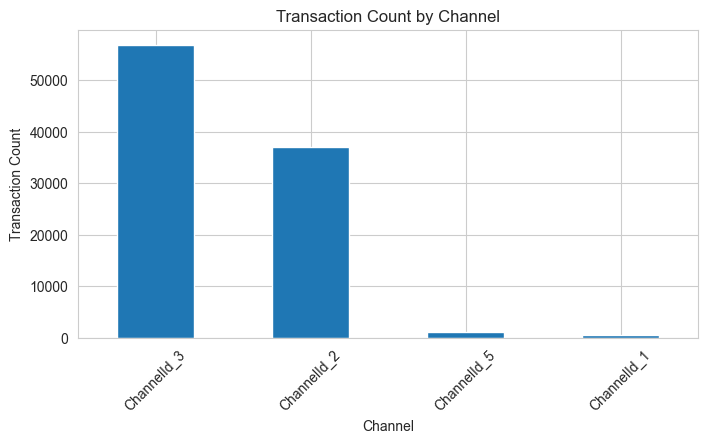

In [35]:
plt.figure(figsize=(8, 4))
df["ChannelId"].value_counts().plot(kind="bar")
plt.title("Transaction Count by Channel")
plt.xlabel("Channel")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.show()

In [36]:
df["TransactionStartTime"] = pd.to_datetime(df["TransactionStartTime"])

df["TransactionHour"] = df["TransactionStartTime"].dt.hour
df["TransactionDay"] = df["TransactionStartTime"].dt.day
df["TransactionMonth"] = df["TransactionStartTime"].dt.month
df["TransactionYear"] = df["TransactionStartTime"].dt.year

df[["TransactionStartTime", "TransactionHour", "TransactionDay", "TransactionMonth", "TransactionYear"]].head()

,TransactionStartTime,TransactionHour,TransactionDay,TransactionMonth,TransactionYear
0,2018-11-15 02:18:49+00:00,2,15,11,2018
1,2018-11-15 02:19:08+00:00,2,15,11,2018
2,2018-11-15 02:44:21+00:00,2,15,11,2018
3,2018-11-15 03:32:55+00:00,3,15,11,2018
4,2018-11-15 03:34:21+00:00,3,15,11,2018


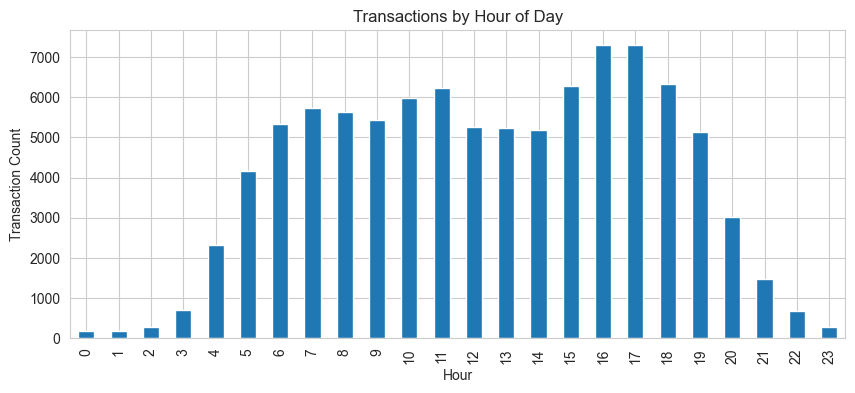

In [37]:
plt.figure(figsize=(10, 4))
df["TransactionHour"].value_counts().sort_index().plot(kind="bar")
plt.title("Transactions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Transaction Count")
plt.show()

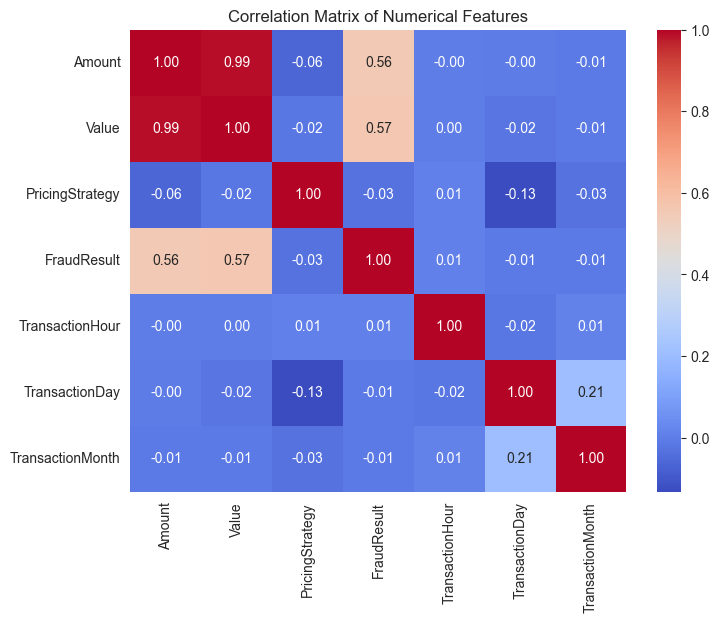

In [38]:
corr_cols = ["Amount", "Value", "PricingStrategy", "FraudResult", 
             "TransactionHour", "TransactionDay", "TransactionMonth"]

corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

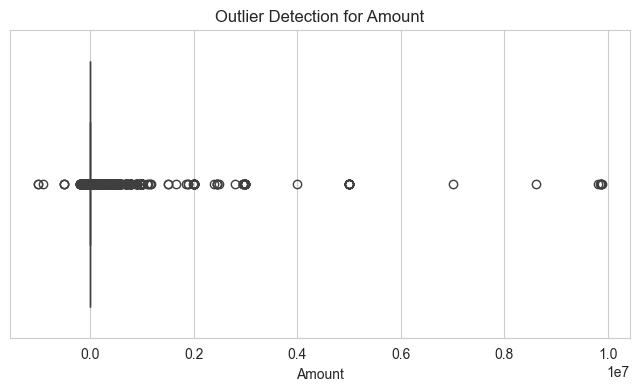

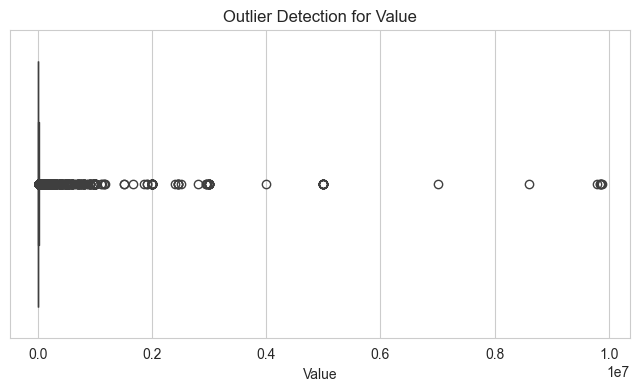

In [39]:
for col in ["Amount", "Value"]:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection for {col}")
    plt.show()

In [40]:
customer_features = df.groupby("CustomerId").agg(
    total_transaction_amount=("Amount", "sum"),
    average_transaction_amount=("Amount", "mean"),
    transaction_count=("TransactionId", "count"),
    std_transaction_amount=("Amount", "std"),
    total_transaction_value=("Value", "sum"),
    average_transaction_value=("Value", "mean"),
    fraud_count=("FraudResult", "sum"),
    first_transaction=("TransactionStartTime", "min"),
    last_transaction=("TransactionStartTime", "max")
).reset_index()

customer_features["std_transaction_amount"] = customer_features["std_transaction_amount"].fillna(0)

customer_features.head()

,CustomerId,total_transaction_amount,average_transaction_amount,transaction_count,std_transaction_amount,total_transaction_value,average_transaction_value,fraud_count,first_transaction,last_transaction
0,CustomerId_1,-10000.0,-10000.000000,1,0.000000,10000,10000.000000,0,2018-11-21 16:49:14+00:00,2018-11-21 16:49:14+00:00
1,CustomerId_10,-10000.0,-10000.000000,1,0.000000,10000,10000.000000,0,2018-11-21 16:49:09+00:00,2018-11-21 16:49:09+00:00
2,CustomerId_1001,20000.0,4000.000000,5,6558.963333,30400,6080.000000,0,2018-11-16 07:53:19+00:00,2018-11-16 08:20:39+00:00
3,CustomerId_1002,4225.0,384.090909,11,560.498966,4775,434.090909,0,2018-11-15 18:50:09+00:00,2019-01-18 10:05:00+00:00
4,CustomerId_1003,20000.0,3333.333333,6,6030.478146,32000,5333.333333,0,2019-02-01 14:58:07+00:00,2019-02-01 15:04:51+00:00


In [41]:
customer_features.describe()

,total_transaction_amount,average_transaction_amount,transaction_count,std_transaction_amount,total_transaction_value,average_transaction_value,fraud_count
count,3.742000e+03,3.742000e+03,3742.000000,3.742000e+03,3.742000e+03,3.742000e+03,3742.000000
mean,1.717377e+05,1.571562e+04,25.564404,1.360517e+04,2.531025e+05,1.875612e+04,0.051577
std,2.717305e+06,1.676991e+05,96.929602,9.689344e+04,2.715877e+06,1.674529e+05,0.774328
min,-1.049000e+08,-4.250000e+05,1.000000,0.000000e+00,5.000000e+01,5.000000e+01,0.000000
25%,4.077438e+03,1.000000e+03,2.000000,5.011411e+02,6.500000e+03,1.160655e+03,0.000000
50%,2.000000e+04,2.583846e+03,7.000000,3.184898e+03,3.200000e+04,3.950000e+03,0.000000
75%,7.996775e+04,4.877614e+03,20.000000,6.745369e+03,1.020600e+05,7.096039e+03,0.000000
max,8.345124e+07,8.601821e+06,4091.000000,3.309916e+06,1.049000e+08,8.601821e+06,31.000000


In [42]:
customer_features.sort_values("transaction_count", ascending=False).head(10)

,CustomerId,total_transaction_amount,average_transaction_amount,transaction_count,std_transaction_amount,total_transaction_value,average_transaction_value,fraud_count,first_transaction,last_transaction
3478,CustomerId_7343,-104900000.0,-25641.652408,4091,12952.599898,104900000,25641.652408,0,2018-11-16 12:55:29+00:00,2019-01-15 13:24:34+00:00
1969,CustomerId_3634,2628793.0,1260.811990,2085,5388.206928,2726207,1307.533333,0,2018-12-12 09:59:00+00:00,2019-01-10 17:18:10+00:00
3390,CustomerId_647,3633564.0,1944.121990,1869,7715.389537,3905264,2089.493847,0,2018-11-29 14:32:42+00:00,2019-02-12 19:21:52+00:00
66,CustomerId_1096,1949226.0,2486.257653,784,17819.372757,2041334,2603.742347,0,2019-01-11 21:41:48+00:00,2019-02-07 07:39:51+00:00
2271,CustomerId_4033,1768355.5,2272.950514,778,10382.687289,1927834,2477.935733,0,2018-11-15 08:45:01+00:00,2019-02-01 16:20:42+00:00
1494,CustomerId_3066,1119116.0,1828.620915,612,5212.148703,1171282,1913.859477,0,2018-12-18 07:45:35+00:00,2019-02-12 17:00:29+00:00
1072,CustomerId_2528,1695194.3,2779.007049,610,22872.844887,1868148,3062.537705,1,2018-11-30 08:36:08+00:00,2019-01-25 15:36:01+00:00
1224,CustomerId_2728,1250976.6,2134.772355,586,5268.094459,1340378,2287.334471,0,2018-11-15 05:06:25+00:00,2019-02-13 06:03:16+00:00
1504,CustomerId_3078,2438140.0,4255.043630,573,22554.029939,2541260,4435.008726,0,2019-01-19 11:50:02+00:00,2019-02-13 09:54:09+00:00
3605,CustomerId_806,2002972.8,3596.001436,557,38535.621914,2097380,3765.493716,1,2018-12-21 19:24:11+00:00,2019-02-11 20:14:36+00:00


In [43]:
snapshot_date = df["TransactionStartTime"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerId").agg(
    Recency=("TransactionStartTime", lambda x: (snapshot_date - x.max()).days),
    Frequency=("TransactionId", "count"),
    Monetary=("Value", "sum")
).reset_index()

rfm.head()

,CustomerId,Recency,Frequency,Monetary
0,CustomerId_1,84,1,10000
1,CustomerId_10,84,1,10000
2,CustomerId_1001,90,5,30400
3,CustomerId_1002,26,11,4775
4,CustomerId_1003,12,6,32000


In [44]:
rfm.describe()

,Recency,Frequency,Monetary
count,3742.000000,3742.000000,3.742000e+03
mean,31.461251,25.564404,2.531025e+05
std,27.118932,96.929602,2.715877e+06
min,1.000000,1.000000,5.000000e+01
25%,6.000000,2.000000,6.500000e+03
50%,25.000000,7.000000,3.200000e+04
75%,54.000000,20.000000,1.020600e+05
max,91.000000,4091.000000,1.049000e+08


# Key Interim EDA Insights

## 1. The dataset is highly suitable for behavioral credit risk modeling

The Xente transaction dataset captures detailed customer purchasing behavior, transaction timing, product interactions, and financial activity patterns that can later support customer-level credit risk assessment.

## 2. Transaction distributions are heavily skewed and contain substantial outliers

Most transactions are relatively small while a minority are extremely large. This indicates the need for normalization, scaling, and transformation strategies to improve model stability and predictive reliability.

## 3. Product categories and transaction channels demonstrate meaningful behavioral variation

Customer activity differs substantially across product categories, pricing strategies, and transaction channels. These behavioral differences are expected to contribute important predictive signals during feature engineering.

## 4. Customer-level aggregation is essential for credit scoring

Credit decisions are made at the customer level rather than the transaction level. Therefore, transaction-level records must later be aggregated into customer behavioral summaries for effective risk prediction.

## 5. RFM behavioral analysis provides a defensible foundation for proxy risk modeling

Since the dataset lacks a direct default label, Recency, Frequency, and Monetary (RFM) behavioral metrics provide a practical and explainable strategy for constructing a proxy high-risk target variable aligned with behavioral credit risk segmentation principles.

## 6. The exploratory findings directly support future modeling and regulatory objectives

The EDA findings help identify preprocessing requirements, behavioral predictors, potential sources of model bias, and feature engineering opportunities that will later contribute to interpretable and regulator-friendly credit scoring models aligned with Basel II expectations.


# Modeling and Regulatory Implications

The exploratory analysis demonstrates that customer transaction behavior contains measurable behavioral patterns that can later support proxy credit risk modeling.

The observed skewness, outliers, class imbalance, and categorical behavioral differences indicate that preprocessing, feature engineering, normalization, and customer-level aggregation will be critical for reliable model development.

The findings also reinforce the importance of interpretability and documentation in regulated financial systems. Future modeling stages will therefore balance predictive performance with explainability to support Basel II-aligned risk assessment and responsible lending decisions at Bati Bank.
